# EDA Process Overview

Steps taken in the EDA process

1. Step 1: Environment Setup (Auto Check & Install)
2. Step 2: Automatic Data Loading
3. Step 3: General Data Cleaning
4. Step 4: Specific Data Cleaning
5. Step 5: Feature Engineering
6. Step 6: Interactive EDA Dashboard (Dash)
7. Step 7: Insights
8. Step 8: Business Implications
9. Step 9: Machine Learning Model Evaluation

Note: Detail explanation is in the each step markdown below. 


# Step 1: Environment Setup (Auto Check & Install)

Step 1.1 Purpose: Check the Python version install in jupyter notebook

In [1]:
import sys
print("Python version:", sys.version)

# Check pip
try:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "--version"],
        capture_output=True,
        text=True,
        check=True
    )
    print("pip version:", result.stdout.strip())
except Exception as e:
    print("[ERROR] pip is not available:", e)

Python version: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
[ERROR] pip is not available: name 'subprocess' is not defined


Step 1.2 Purpose: 
1. The follow code below is to automatically check if the require python library is install in jupyter notebook. If it is not install, it will install the library (Pandas, numpy, plotly, dash, request, scikit-learn).

2. Pandas, numpy is for data cleaning. Ploty is to plot graph, bar chart while dash is create dashboard. scikit-learn is machine learning to assist in predicting result using 1,0. 

Conlusion: All required packages will be installed.

In [2]:
import sys
import subprocess
from importlib.metadata import version, PackageNotFoundError
from packaging.requirements import Requirement

required_packages = [
    "pandas==3.0.2",
    "numpy==2.4.4",
    "plotly==6.7.0",
    "dash==4.1.0",
    "requests==2.33.1",
    "scikit-learn==1.8.0",
    "scipy==1.17.1",
    "lightgbm==4.6.0",
    "torch==2.12.0",
    "torchvision==0.27.0",
    "torchaudio==2.11.0",
    "transformers==5.10.1",
    "typing-extensions==4.16.0",
    "huggingface-hub==1.24.0",
    "tokenizers==0.22.2",
    "safetensors==0.7.0",
    "sentence-transformers==5.5.1",
    "matplotlib==3.11.1",
    "seaborn==0.13.2",
    "pyarrow==24.0.0"
]


def install_missing_packages(packages):
    missing = []

    for package in packages:
        requirement = Requirement(package)
        package_name = requirement.name

        try:
            installed_version = version(package_name)

            # Check whether installed version satisfies the requirement
            if requirement.specifier and installed_version not in requirement.specifier:
                print(
                    f"[INFO] {package_name} version {installed_version} "
                    f"does not satisfy {requirement.specifier}"
                )
                missing.append(package)

        except PackageNotFoundError:
            print(f"[INFO] {package_name} is not installed.")
            missing.append(package)

    if missing:
        print("\nInstalling missing/incompatible packages:")
        for package in missing:
            print(f"  - {package}")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            *missing
        ])

        print("\n[INFO] Package installation completed.")

    else:
        print("[INFO] All required packages are already installed.")


install_missing_packages(required_packages)

[INFO] All required packages are already installed.


Step 1.3 Purpose:
import python library for ETL, data analysis and machine learning purpose so that it can be use for step 2 onwards.

Conlusion: All required library will be imported.

In [3]:
import sklearn

print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.8.0


In [4]:
import pandas as pd
import numpy as np
import sqlite3
import requests
import os
import re

#chi2_contingency to check missing data
from scipy.stats import chi2_contingency

# Visualization
import plotly.express as px
import plotly.graph_objects as go

# Dashboard
from dash import Dash, dcc, html, Input, Output

Note: Step 2 and 3 is generic code which make it usable for any type of data and reduce the need to rewrite need code. This step will speed up the EDA work for each new project.

# Step 2: Automatic Data Loading

Step 2 Purpose: 

1. Automatically load *.db file found in data folder into sql reader. It can load single or multiple *.db file and delete duplicate data by checking if there is duplicate data from column 2 to 15.

2. A preview of the dataset will be generated as output to have a basis understanding of the dataset.

Conlusion: *.db file found in data folder will be automatically loaded.

Step 2.1: Check the different table for common identifier which is client_email

In [5]:
import os
import glob
import sqlite3
import pandas as pd

# =========================
# CONFIG
# =========================
config = {
    "db_dir": "data/",
    "db_path": None,
    "multi_db": True,           # True = load all DBs in folder, False = single DB
}


def get_all_tables(conn):
    tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table';",
        conn
    )
    return tables["name"].tolist()

db_files = glob.glob(os.path.join(config["db_dir"], "*.db"))

for db_path in db_files:

    print("\n" + "=" * 80)
    print(f"DATABASE: {os.path.basename(db_path)}")
    print("=" * 80)

    conn = sqlite3.connect(db_path)

    tables = get_all_tables(conn)

    for table in tables:
        print(f"\nTABLE: {table}")

        cols = pd.read_sql(
            f'SELECT * FROM "{table}" LIMIT 1',
            conn
        ).columns

        print(cols.tolist())

    conn.close()


DATABASE: hotel.db

TABLE: bookings
['Unnamed: 0', 'booking_id', 'client_email', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'promo_code']

TABLE: reviews
['client_email', 'rating', 'comments']


In [6]:
import os
import glob
import sqlite3
import pandas as pd

# =========================
# CONFIG
# =========================
config = {
    "db_dir": "data/",
    "db_path": None,
    "multi_db": True,           # True = load all DBs in folder, False = single DB
    "join_key": "client_email"   # CHANGE THIS TO YOUR COMMON COLUMN
}

# =========================
# AUTO TABLE DETECTION
# =========================
def get_first_table(conn):
    tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table';",
        conn
    )

    if tables.empty:
        raise ValueError("No tables found in database.")

    return tables.iloc[0, 0]

# =========================
# GET ALL TABLES
# =========================
def get_all_tables(conn):
    tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table';",
        conn
    )

    if tables.empty:
        raise ValueError("No tables found in database.")

    return tables["name"].tolist()

# =========================
# LOAD & MERGE ALL TABLES
# =========================
def load_and_merge_tables(conn, join_key):
    tables = get_all_tables(conn)

    print(f"[INFO] Found tables: {tables}")

    dfs = []

    for table in tables:
        print(f"[INFO] Loading table '{table}'")

        df = pd.read_sql(
            f'SELECT * FROM "{table}"',
            conn
        )

        print(f"[INFO] Shape: {df.shape}")

        dfs.append(df)

    if len(dfs) == 1:
        return dfs[0]

    # Verify join key exists
    for i, df in enumerate(dfs):
        if join_key not in df.columns:
            raise ValueError(
                f"Join key '{join_key}' not found in table '{tables[i]}'.\n"
                f"Columns available: {df.columns.tolist()}"
            )

    merged_df = dfs[0]

    for df in dfs[1:]:
        merged_df = pd.merge(
            merged_df,
            df,
            on=join_key,
            how="outer"
        )

    print(f"[INFO] Merged tables shape: {merged_df.shape}")

    return merged_df

# =========================
# LOAD SINGLE DB
# =========================
def load_single_db(db_path, join_key):
    if not db_path or not os.path.exists(db_path):
        raise ValueError(f"Invalid db_path: {db_path}")

    conn = sqlite3.connect(db_path)

    print(f"[INFO] Loading database: {db_path}")

    df = load_and_merge_tables(conn, join_key)

    conn.close()

    return df

# =========================
# LOAD MULTIPLE DBs
# =========================
def load_multiple_dbs(db_dir, join_key):
    db_files = glob.glob(os.path.join(db_dir, "*.db"))

    if not db_files:
        raise ValueError(f"No .db files found in {db_dir}")

    all_dfs = []

    for db_path in db_files:
        print(f"\n[INFO] Loading {db_path}")

        conn = sqlite3.connect(db_path)

        df = load_and_merge_tables(conn, join_key)

        conn.close()

        # track source
        df["source_db"] = os.path.basename(db_path)

        all_dfs.append(df)

    if not all_dfs:
        raise ValueError("No data loaded from DBs")

    merged_df = pd.concat(all_dfs, ignore_index=True)

    print(f"[INFO] Merged {len(db_files)} databases")
    print(f"[INFO] Final shape: {merged_df.shape}")

    return merged_df

# =========================
# MAIN LOADER
# =========================
def load_data(config):
    if config["multi_db"]:
        return load_multiple_dbs(
            config["db_dir"],
            config["join_key"]
        )
    else:
        return load_single_db(
            config["db_path"],
            config["join_key"]
        )

# =========================
# REMOVE DUPLICATES
# =========================
def remove_duplicates(df):
    # take columns 2 to 15
    key_cols = df.columns[2:16].tolist()

    if len(key_cols) >= 2:
        df = df.drop_duplicates(
            subset=key_cols,
            keep="first"
        )
    else:
        df = df.drop_duplicates()

    print(f"[INFO] After deduplication: {df.shape}")

    return df

# =========================
# RUN PIPELINE
# =========================
if __name__ == "__main__":

    # 1. Load data
    df = load_data(config)

    print("[INFO] Raw shape:", df.shape)

    # 2. Clean duplicates
    df = remove_duplicates(df)

    print("\n========== DATA PREVIEW ==========")

    print("[INFO] Columns:")
    print(df.columns.tolist())

    print("\n[INFO] Sample rows:")
    print(df.head(10))

    print("\n[INFO] Data types:")
    print(df.dtypes)

    print("\n[INFO] Missing values (top 15):")
    print(df.isna().sum().sort_values(ascending=False).head(15))

    # 3. Preview
    print(df.head())


[INFO] Loading data\hotel.db
[INFO] Found tables: ['bookings', 'reviews']
[INFO] Loading table 'bookings'
[INFO] Shape: (118549, 36)
[INFO] Loading table 'reviews'
[INFO] Shape: (17583, 3)
[INFO] Merged tables shape: (118600, 38)
[INFO] Merged 1 databases
[INFO] Final shape: (118600, 39)
[INFO] Raw shape: (118600, 39)
[INFO] After deduplication: (118196, 39)

========== DATA PREVIEW ==========
[INFO] Columns:
['Unnamed: 0', 'booking_id', 'client_email', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', '

In [7]:
import os
import glob
import sqlite3
import pandas as pd

# =========================
# CONFIG
# =========================
config = {
    "db_dir": "data/",
    "db_path": None,
    "multi_db": True,           # True = load all DBs in folder, False = single DB
}


def get_all_tables(conn):
    tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table';",
        conn
    )
    return tables["name"].tolist()

db_files = glob.glob(os.path.join(config["db_dir"], "*.db"))

for db_path in db_files:

    print("\n" + "=" * 80)
    print(f"DATABASE: {os.path.basename(db_path)}")
    print("=" * 80)

    conn = sqlite3.connect(db_path)

    tables = get_all_tables(conn)

    for table in tables:
        print(f"\nTABLE: {table}")

        cols = pd.read_sql(
            f'SELECT * FROM "{table}" LIMIT 1',
            conn
        ).columns

        print(cols.tolist())

    conn.close()


DATABASE: hotel.db

TABLE: bookings
['Unnamed: 0', 'booking_id', 'client_email', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'promo_code']

TABLE: reviews
['client_email', 'rating', 'comments']


# Step 3: General Data Cleaning

Step 3 Assumption:

1. Assumption - there is data issue with the data set which resulted in some row where there is empty data. This data issue will result in downstream data analysis in step 5 to 9. Therefore, to avoid such an issue, a general code is used to remove any row where at least one cell has NaN. This will remove data issue.

2. Using IterativeImputer (High Accuracy) from Scikit-Learn is possible which can be done after the feature engineering to impute the missing data as it need to be 1/0.  

3. In real production, using IterativeImputer to impute data is the last resort as it is computationally expensive and slow for very large datasets. So normally user will patch the missing data or seek their concurrence on how to fix missing data at input data entry point.

4. Dropping throws away incomplete records to preserve data integrity, while IterativeImputer is a multivariate machine learning technique that predicts and fills in missing values based on relationships with other features. Therefore the assumption in this task is use IterativeImputer as data is Missing at Random (MAR), IterativeImputer is almost always better than removing missing data. Removing data introduces statistical bias and reduces your sample size, whereas IterativeImputer uses relationships in your other features to estimate the true values accurately. Dropping nearly 70% of your dataset will severely damage your machine learning model by destroying statistical power and introducing massive bias.


Step 3.1 Purpose: 

1. General cleaning (remove duplicate, remove any row where there at least 1 cell is empty, convert all text to lowercase to avoid big and small cap issue so that there will not have any big cap small cap issues)

2. The code below will still generate a statistics of the number of the rows before removal and after removal to give an idea how bad the quality of the data.

3. A further code could be insert to generate an output in csv file for row where at least one cell has NaN. This will remove data issue so that it can be investigate by the data owner to determine if the data can be patch. 

4. IterativeImputer is use to fill in the missing data as the CHI-SQUARE TEST on the data found that data is missing at random.

Conclusion: There are missing values and most of it are at random which makes IterativeImputer to impute missing data suitable. To confirm that, will use plolty to visualise the data distribution in the next few steps.

In [8]:
# Remove duplicates
df = df.drop_duplicates()

#removes: leading spaces & trailing spaces but keeps spaces inside the text

df = df.apply(
    lambda col: col.str.strip() if col.dtype == "object" else col
)



# Convert all text to lowercase
df = df.apply(lambda col: col.map(lambda x: x.lower() if isinstance(x, str) else x))

# Apply absolute value only to numeric columns
df[df.select_dtypes(include=[np.number]).columns] = df.select_dtypes(include=[np.number]).abs()



print("\n========== MISSING DATA RANDOMNESS ANALYSIS ==========")

# =========================
# FIND COLUMNS WITH MISSING VALUES
# =========================
missing_summary = df.isna().sum()

# Keep only columns with missing values
missing_summary = missing_summary[missing_summary > 0]

print("\n[INFO] Missing columns:")
print(missing_summary)

results = []

# =========================
# CHI-SQUARE TEST
# =========================
for col in missing_summary.index:

    print(f"\n========== Testing Missingness of: {col} ==========")

    missing_flag = df[col].isna()

    random_cols = []
    non_random_cols = []

    for compare_col in df.select_dtypes(include="object").columns:

        if compare_col == col:
            continue

        try:

            contingency = pd.crosstab(
                df[compare_col],
                missing_flag
            )

            # Skip invalid tables
            if contingency.shape[0] < 2 or contingency.shape[1] < 2:
                continue

            chi2, p, dof, expected = chi2_contingency(contingency)

            if p < 0.05:
                non_random_cols.append(
                    f"{compare_col} (p={p:.5f})"
                )
            else:
                random_cols.append(
                    f"{compare_col} (p={p:.5f})"
                )

        except Exception as e:
            print(f"[WARNING] Could not test {compare_col}: {e}")

    # Output per missing column
    print("\nLikely NON-RANDOM relationships:")
    if non_random_cols:
        for item in non_random_cols:
            print(f" - {item}")
    else:
        print(" None")

    print("\nLikely RANDOM relationships:")
    if random_cols:
        for item in random_cols:
            print(f" - {item}")
    else:
        print(" None")

    # Store summary
    results.append({
        "missing_column": col,
        "non_random_count": len(non_random_cols),
        "random_count": len(random_cols)
    })

# =========================
# FINAL SUMMARY
# =========================
summary_df = pd.DataFrame(results)

print("\n========== FINAL SUMMARY ==========")
print(summary_df)


========== MISSING DATA RANDOMNESS ANALYSIS ==========

[INFO] Missing columns:
rating      100664
comments    100664
dtype: int64

========== Testing Missingness of: rating ==========


C:\Users\ong\AppData\Local\Temp\ipykernel_17056\1721252516.py:47: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for compare_col in df.select_dtypes(include="object").columns:



Likely NON-RANDOM relationships:
 - hotel (p=0.00000)
 - is_canceled (p=0.00000)
 - lead_time (p=0.00000)
 - arrival_date_year (p=0.00000)
 - arrival_date_month (p=0.00000)
 - arrival_date_week_number (p=0.00000)
 - arrival_date_day_of_month (p=0.00053)
 - stays_in_weekend_nights (p=0.01305)
 - stays_in_week_nights (p=0.00000)
 - adults (p=0.00053)
 - children (p=0.00000)
 - babies (p=0.00000)
 - meal (p=0.02914)
 - country (p=0.00000)
 - market_segment (p=0.00000)
 - distribution_channel (p=0.00000)
 - is_repeated_guest (p=0.00000)
 - previous_cancellations (p=0.00000)
 - previous_bookings_not_canceled (p=0.00000)
 - reserved_room_type (p=0.00012)
 - assigned_room_type (p=0.00000)
 - booking_changes (p=0.00000)
 - deposit_type (p=0.00000)
 - agent (p=0.00000)
 - days_in_waiting_list (p=0.00000)
 - customer_type (p=0.00000)
 - adr (p=0.00000)
 - required_car_parking_spaces (p=0.00000)
 - total_of_special_requests (p=0.00000)
 - reservation_status (p=0.00000)
 - reservation_status_date

C:\Users\ong\AppData\Local\Temp\ipykernel_17056\1721252516.py:47: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for compare_col in df.select_dtypes(include="object").columns:



Likely NON-RANDOM relationships:
 - hotel (p=0.00000)
 - is_canceled (p=0.00000)
 - lead_time (p=0.00000)
 - arrival_date_year (p=0.00000)
 - arrival_date_month (p=0.00000)
 - arrival_date_week_number (p=0.00000)
 - arrival_date_day_of_month (p=0.00053)
 - stays_in_weekend_nights (p=0.01305)
 - stays_in_week_nights (p=0.00000)
 - adults (p=0.00053)
 - children (p=0.00000)
 - babies (p=0.00000)
 - meal (p=0.02914)
 - country (p=0.00000)
 - market_segment (p=0.00000)
 - distribution_channel (p=0.00000)
 - is_repeated_guest (p=0.00000)
 - previous_cancellations (p=0.00000)
 - previous_bookings_not_canceled (p=0.00000)
 - reserved_room_type (p=0.00012)
 - assigned_room_type (p=0.00000)
 - booking_changes (p=0.00000)
 - deposit_type (p=0.00000)
 - agent (p=0.00000)
 - days_in_waiting_list (p=0.00000)
 - customer_type (p=0.00000)
 - adr (p=0.00000)
 - required_car_parking_spaces (p=0.00000)
 - total_of_special_requests (p=0.00000)
 - reservation_status (p=0.00000)
 - reservation_status_date

Step 3.2 Purpose: 
1. Check the number & percentage of row with missing data 

In [9]:
# =========================
# ORIGINAL ROW COUNT
# =========================
total_rows = df.shape[0]

# =========================
# COUNT NaN + "none"
# =========================

nan_counts = df.isna().sum()

none_counts = df.apply(
    lambda col: col.astype(str).str.lower().eq("none").sum()
)

total_missing = nan_counts + none_counts

# =========================
# PERCENTAGE CALCULATION
# =========================

nan_pct = (nan_counts / total_rows) * 100
none_pct = (none_counts / total_rows) * 100
total_missing_pct = (total_missing / total_rows) * 100

# =========================
# REPORT
# =========================

print("\n========== MISSING VALUE REPORT ==========")

print("\n[NaN counts per column]")
print(nan_counts)

print("\n[NaN % per column]")
print(nan_pct.round(2))

print("\n['none' counts per column]")
print(none_counts)

print("\n['none' % per column]")
print(none_pct.round(2))

print("\n[Total missing (NaN + none)]")
print(total_missing)

print("\n[Total missing % (NaN + none)]")
print(total_missing_pct.round(2))


# =========================
# ROW-LEVEL INSIGHT (optional but useful)
# =========================

nan_rows = df.isna().any(axis=1).sum()

none_rows = df.astype(str).apply(lambda col: col.str.lower().eq("none")).any(axis=1).sum()

print("\n========== ROW LEVEL SUMMARY ==========")

print(f"Total rows: {total_rows}")
print(f"Rows containing NaN: {nan_rows} ({nan_rows/total_rows*100:.2f}%)")
print(f"Rows containing 'none': {none_rows} ({none_rows/total_rows*100:.2f}%)")


========== MISSING VALUE REPORT ==========

[NaN counts per column]
Unnamed: 0                             0
booking_id                             0
client_email                           0
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               0
babies                                 0
meal                                   0
country                                0
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type           

Step 3.3 Purpose: 

1. Check each column for unique data. Should not have nan or negative value. nan means there is no data.

2. This code will help to identify if there is a need for specific data cleaning where the data is not consistent (eg. mix of number and word in a column, only word in column which need to be converted to 1 or 0 for statistic counting purpose or negative number which will affect the count) via printing of unique values.

Conclusion: Unique data for each column is generate out for analysis.

In [10]:
# Print unique values for all columns except booking_id and Unnamed: 0
for col in df.columns:
    if col not in ["booking_id", "Unnamed: 0"]:
        print(f"\n{col} unique values:")
        print(df[col].unique())



client_email unique values:
<ArrowStringArray>
['aaron.chan1004@yahoo.com.sg',  'aaron.chan1008@outlook.com',
    'aaron.chan1050@gmail.com',   'aaron.chan1056@icloud.com',
  'aaron.chan1145@hotmail.com', 'aaron.chan1206@yahoo.com.sg',
    'aaron.chan1306@gmail.com',   'aaron.chan1382@icloud.com',
    'aaron.chan1450@gmail.com',  'aaron.chan1462@hotmail.com',
 ...
      'zhen.yeo9694@gmail.com',      'zhen.yeo9727@gmail.com',
    'zhen.yeo9730@hotmail.com',    'zhen.yeo9756@hotmail.com',
     'zhen.yeo9765@icloud.com',   'zhen.yeo9808@yahoo.com.sg',
    'zhen.yeo9858@hotmail.com',    'zhen.yeo9937@hotmail.com',
    'zhen.yeo9943@outlook.com',      'zhen.yeo9954@gmail.com']
Length: 118196, dtype: str

hotel unique values:
<ArrowStringArray>
['city hotel', 'airport hotel']
Length: 2, dtype: str

is_canceled unique values:
<ArrowStringArray>
['1', '0', 'no', 'false', 'true', 'yes']
Length: 6, dtype: str

lead_time unique values:
<ArrowStringArray>
[      '55',       '14',      '109',    

# Step 4: Specific Data Cleaning

Step 4.1 Purpose: 

1. General cleaning (remove duplicate, remove any row where there at least 1 cell is empty, convert all text to lowercase to avoid big and small cap issue so that there will not have any big cap small cap issues). Run this code again to ensure it is consistence.

2. Manually replace data error to ensure there is data consistency.

In [11]:
# =========================
# Step 4.1 Remove duplicates,Convert lowercase & absolute value
# =========================


# Remove duplicates
df = df.drop_duplicates()

#removes: leading spaces & trailing spaces but keeps spaces inside the text

df = df.apply(
    lambda col: col.str.strip() if col.dtype == "object" else col
)


# Convert all text to lowercase
df = df.apply(lambda col: col.map(lambda x: x.lower() if isinstance(x, str) else x))

# Apply absolute value only to numeric columns
df[df.select_dtypes(include=[np.number]).columns] = df.select_dtypes(include=[np.number]).abs()


df = df.rename(columns={"comments": "comment"})

# Columns that must NEVER be touched
excluded_columns = {"comment", "booking_id", "Unnamed: 0"}

for col in df.columns:

    # Skip excluded columns completely
    if col in excluded_columns:
        continue

    # Only clean other text columns
    if pd.api.types.is_string_dtype(df[col]):
        df[col] = df[col].str.strip()



# Print unique values for all columns except booking_id and Unnamed: 0
for col in df.columns:
    if col not in ["booking_id", "Unnamed: 0"]:
        print(f"\n{col} unique values:")
        print(df[col].unique())


client_email unique values:
<ArrowStringArray>
['aaron.chan1004@yahoo.com.sg',  'aaron.chan1008@outlook.com',
    'aaron.chan1050@gmail.com',   'aaron.chan1056@icloud.com',
  'aaron.chan1145@hotmail.com', 'aaron.chan1206@yahoo.com.sg',
    'aaron.chan1306@gmail.com',   'aaron.chan1382@icloud.com',
    'aaron.chan1450@gmail.com',  'aaron.chan1462@hotmail.com',
 ...
      'zhen.yeo9694@gmail.com',      'zhen.yeo9727@gmail.com',
    'zhen.yeo9730@hotmail.com',    'zhen.yeo9756@hotmail.com',
     'zhen.yeo9765@icloud.com',   'zhen.yeo9808@yahoo.com.sg',
    'zhen.yeo9858@hotmail.com',    'zhen.yeo9937@hotmail.com',
    'zhen.yeo9943@outlook.com',      'zhen.yeo9954@gmail.com']
Length: 118196, dtype: str

hotel unique values:
<ArrowStringArray>
['city hotel', 'airport hotel']
Length: 2, dtype: str

is_canceled unique values:
<ArrowStringArray>
['1', '0', 'no', 'false', 'true', 'yes']
Length: 6, dtype: str

lead_time unique values:
<ArrowStringArray>
[      '55',       '14',      '109',    

In [12]:
# =========================
# Step 4.1.1 Replace data error
# =========================


df['arrival_date_month'] = df['arrival_date_month'].replace({
    'feb': 'february',
    'apr': 'april',
    'oct': 'october',
    'nov': 'november',
    'mar': 'march',
    'jul': 'july',
    'sep': 'september',
    'dec': 'december',
    'aug': 'august',
    'jun': 'june',
    'jan': 'january'
    
})


print(df['arrival_date_month'].unique())


df['meal'] = df['meal'].replace({
    'unknown': np.nan,
    'null': np.nan,
    'na': 'SC (Self Catering)',
    'n/a': 'SC (Self Catering)',
    '-': np.nan,
    '': np.nan,
    'bb': 'BB (Bed & Breakfast)',
    'hb': 'HB (Half Board)',
    'fb': 'FB (Full Board)',
    'sc': 'SC (Self Catering)'
})


print(df['meal'].unique())


df['country'] = df['country'].replace({
    'unknown': np.nan,
    'singapore': 'sgp',
    'australia': 'aus',
    'indonesia': 'idn',
    'taiwan': 'twn',
    'china': 'chn',
    'united kingdom': 'uk',
    'south korea': 'kor',
    'philippines': 'phl',
    'hong kong': 'hk',
    'new zealand': 'nzl',
    'thailand': 'tha',
    'myanmar': 'mmr',
    'united states': 'usa',
    'vietnam': 'vnm',
    'japan': 'jps',
    'malaysia': 'mys',
    'india': 'ind',
    'hkg': 'hk',
    '-': np.nan,
    '': np.nan
})


print(df['country'].unique())


df['market_segment'] = df['market_segment'].replace({
    'unknown': np.nan,
    'offline  ta/to': 'offline-ta/to',
    'offline  ta/t0': 'offline-ta/to',
    'offline ta/to': 'offline-ta/to',
    'offline ta/t0': 'offline-ta/to',
    'onlin ta': 'online-ta',
    'online  ta': 'online-ta',
    'online ta': 'online-ta',
    'nan': np.nan,
    'null': np.nan,
    'na': np.nan,
    '-': np.nan,
    '': np.nan
})


print(df['market_segment'].unique())


df['distribution_channel'] = df['distribution_channel'].replace({
    'unknown': np.nan,
    'unknown': np.nan,
    'null': np.nan,
    '-': np.nan,
    '': np.nan
})


print(df['distribution_channel'].unique())


df['deposit_type'] = df['deposit_type'].replace({
    'no depost': 'no-deposit',
    'no  deposit': 'no-deposit',
    'no deposit': 'no-deposit',
    'non refund': 'non-refund',
    'non  refund': 'non-refund',
    'unknown': np.nan,
    'null': np.nan,
    '-': np.nan,
    '': np.nan
})


print(df['deposit_type'].unique())



df['customer_type'] = df['customer_type'].replace({
    'transiant': 'transient',
    'unknown': np.nan,
    'null': np.nan,
    'na': np.nan,
    'n/a': np.nan,
    '-': np.nan,
    '': np.nan
})


print(df['customer_type'].unique())


df['is_canceled'] = df['is_canceled'].replace({
    'no': '0',
    'false': '0',
    'true': '1',
    'yes': '1'
})


print(df['is_canceled'].unique())




<ArrowStringArray>
[      'may',   'january',    'august',   'october',      'june',  'february',
     'march',      'july',     'april', 'september',  'december',  'november']
Length: 12, dtype: str
<ArrowStringArray>
['BB (Bed & Breakfast)',   'SC (Self Catering)',            'undefined',
      'HB (Half Board)',      'FB (Full Board)',                    nan]
Length: 6, dtype: str
<ArrowStringArray>
[  'sgp',   'idn',   'aus',   'usa',   'ind',   'chn',   'phl',    'hk',
   'twn',   'mys',   'oth',   'gbr',   'jpn',   'kor',     nan,   'tha',
   'mmr',   'vnm', 'other',   'jps',    'uk',   'nzl',  'null']
Length: 23, dtype: str
<ArrowStringArray>
['offline-ta/to',     'online-ta',        'groups',        'direct',
     'corporate', 'complementary',      'aviation',             nan,
     'undefined']
Length: 9, dtype: str
<ArrowStringArray>
['ta/to', 'direct', 'corporate', nan, 'gds', 'undefined']
Length: 6, dtype: str
<ArrowStringArray>
['non-refund', 'no-deposit', 'refundable']
Len

Step 4.2 Purpose: 

1. Convert data binary for non date and time data

In [13]:
# =========================
# Step 4.2 Convert to binary
# =========================

cols_to_encode = [
    'hotel',
    'meal',
    'market_segment',
    'distribution_channel',
    'deposit_type',
    'customer_type',
    'reservation_status'
]

mappings = {}

for col in cols_to_encode:

    # keep raw categories
    df[col] = df[col].astype("string")

    # fill missing so mapping is stable
    df[col] = df[col].fillna("missing")

    # create mapping
    uniques = sorted(df[col].unique())

    mapping = {val: idx for idx, val in enumerate(uniques)}

    # apply encoding
    df[col] = df[col].map(mapping).astype(int)

    # store mapping
    mappings[col] = mapping
    
    
reverse_mappings = {
    'hotel': {0: 'city hotel', 1: 'airport hotel'},
    'meal': {0: 'BB (Bed & Breakfast)', 1: 'HB (Half Board)', 2: 'FB (Full Board)', 3: 'SC (Self Catering)', 4: 'undefined', 5: np.nan},
    'market_segment': {0: 'offline-ta/to', 1: 'online-ta', 2: 'groups', 3: 'direct', 4: 'corporate', 
                       5: 'complementary', 6: 'aviation', 7: 'undefined', 8: np.nan},
    'distribution_channel': {0: 'direct', 1: 'corporate', 2: 'gds', 3: 'undefined', 4: 'ta/to', 5: np.nan},
    'deposit_type': {0: 'non-refund', 1: 'no-deposit', 2: 'refundable'},
    'customer_type': {0: 'transient', 1: 'transient-party', 2: 'contract', 3: 'group', 4: np.nan},
    'reservation_status': {0: 'canceled', 1: 'no-show', 2: 'check-out'}
}
    

print(df)
print(mappings)


       Unnamed: 0 booking_id                 client_email  hotel is_canceled  \
0           30463   sg167516  aaron.chan1004@yahoo.com.sg      1           1   
1           42146   sg201345   aaron.chan1008@outlook.com      1           0   
2           70923   sg154005     aaron.chan1050@gmail.com      1           1   
3           89791   sg128063    aaron.chan1056@icloud.com      0           0   
4          108637   sg105629   aaron.chan1145@hotmail.com      0           1   
...           ...        ...                          ...    ...         ...   
118595      12525   sg193428    zhen.yeo9808@yahoo.com.sg      1           0   
118596      93719   sg209914     zhen.yeo9858@hotmail.com      1           0   
118597      22337   sg204396     zhen.yeo9937@hotmail.com      1           0   
118598      46031   sg146816     zhen.yeo9943@outlook.com      1           1   
118599      82366   sg153857       zhen.yeo9954@gmail.com      1           1   

       lead_time arrival_date_year arri

Step 4.2.1 Purpose: Visualise the data in graph format to look at the distribution of the data to set the strategy for filling in missing day


Category column should use mode while numerical column should use median to fill in missing data. However mode and median method is not as accurate as iterative imputer to filling missing values therefore decided to use iterative imputer to fill missing values.

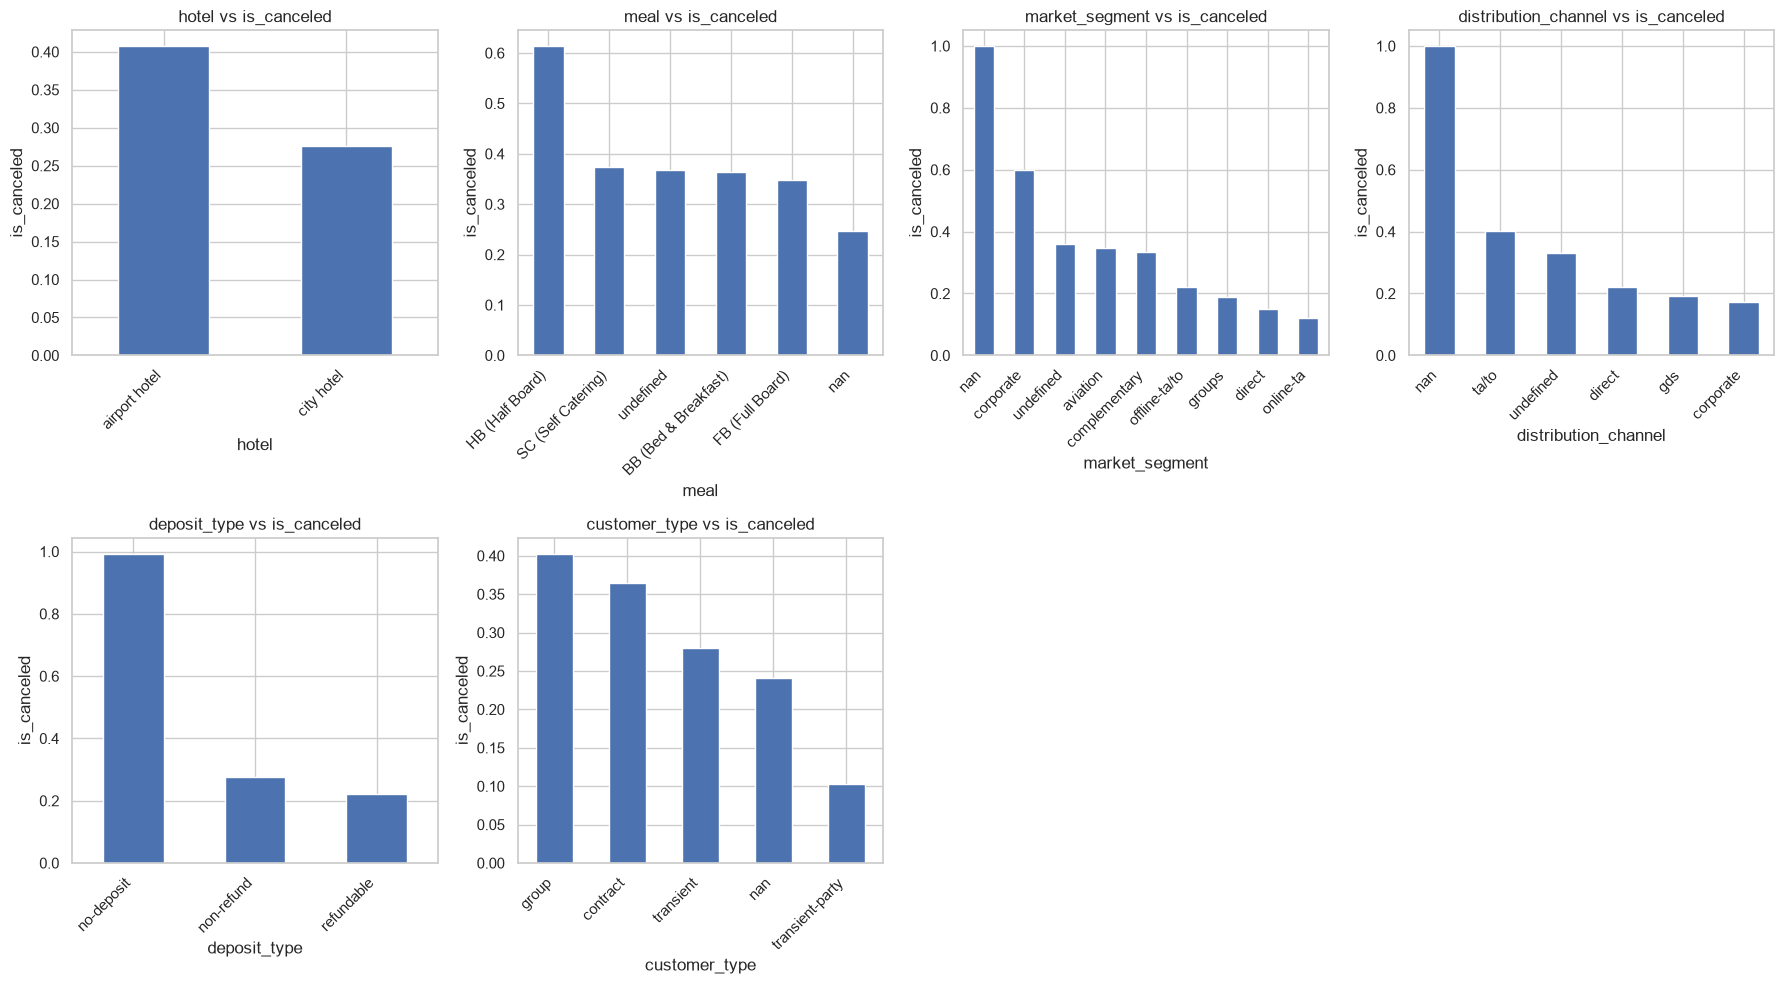

In [14]:
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

target = "is_canceled"

# Convert is_canceled to numeric
df[target] = pd.to_numeric(df[target], errors="coerce")

cols = [
    'hotel',
    'meal',
    'market_segment',
    'distribution_channel',
    'deposit_type',
    'customer_type'
]

plots_per_figure = 8

for start in range(0, len(cols), plots_per_figure):

    plot_cols = cols[start:start + plots_per_figure]

    fig, axes = plt.subplots(2, 4, figsize=(18, 10))
    axes = axes.ravel()

    for ax, col in zip(axes, plot_cols):

        # Calculate cancellation rate
        cancellation_rate = (
            df.groupby(col, dropna=False)[target]
            .mean()
            .sort_values(ascending=False)
        )

        cancellation_rate.plot(
            kind="bar",
            ax=ax
        )

        # Read the existing reverse mapping for this column
        mapping = reverse_mappings[col]

        # Map numeric x-axis values to original labels
        ax.set_xticklabels(
            [
                mapping.get(int(value), str(value))
                if pd.notna(value)
                else "Unknown"
                for value in cancellation_rate.index
            ],
            rotation=45,
            ha="right"
        )

        ax.set_title(f"{col} vs {target}")
        ax.set_xlabel(col)
        ax.set_ylabel("is_canceled")

    # Hide unused plots
    for ax in axes[len(plot_cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

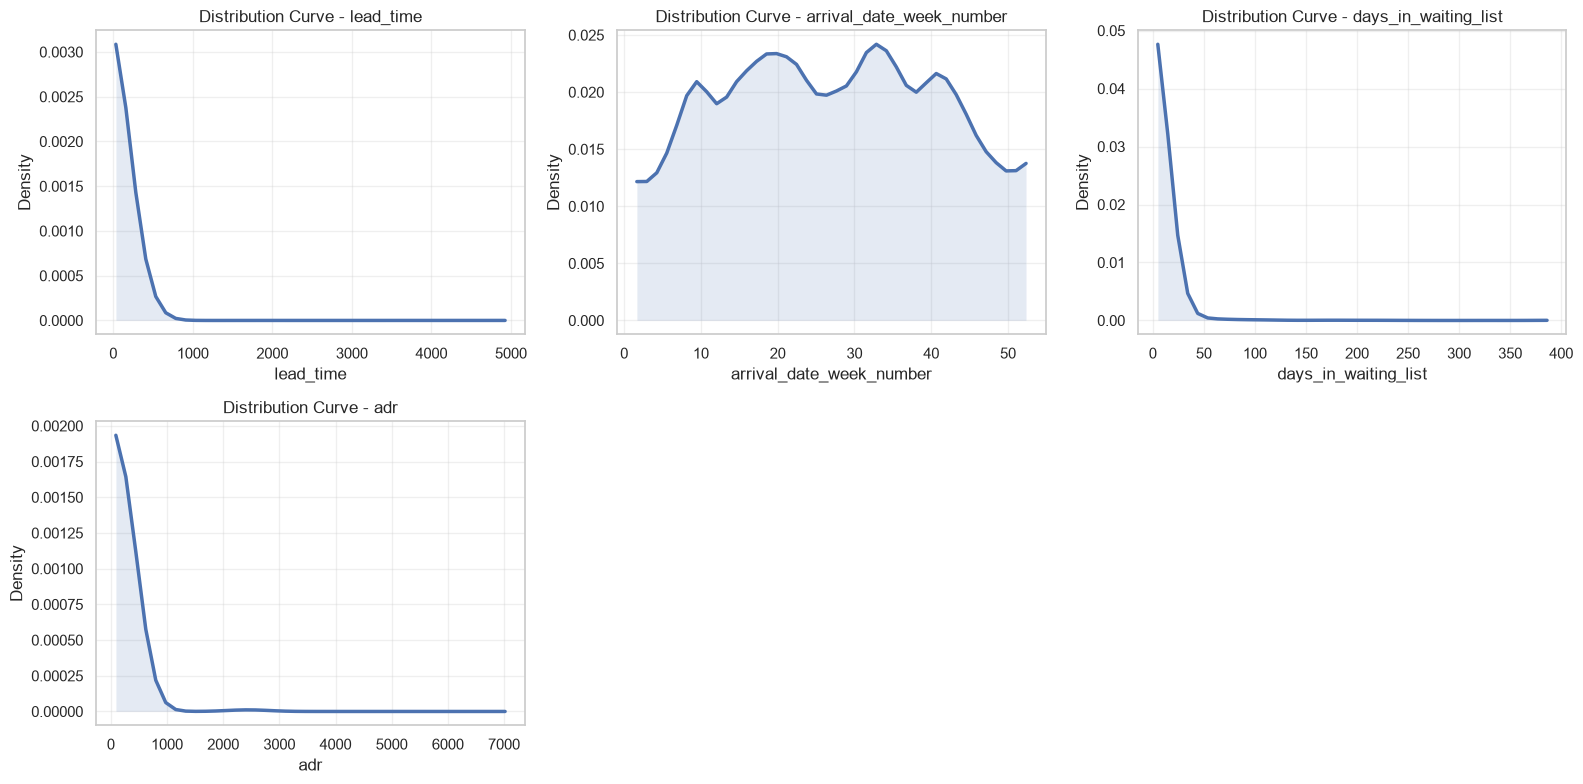

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

num_cols = [
    'lead_time',
    'arrival_date_week_number',
    'days_in_waiting_list',
    'adr'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):

    # --------------------------------------------------------
    # Convert to numeric
    # Invalid values become NaN
    # --------------------------------------------------------
    values = pd.to_numeric(
        df[col],
        errors="coerce"
    ).dropna().to_numpy()

    # Check whether there is usable data
    if len(values) == 0:
        ax.set_title(f"{col} - No numeric data")
        ax.axis("off")
        continue

    # --------------------------------------------------------
    # Remove infinite values
    # --------------------------------------------------------
    values = values[np.isfinite(values)]

    if len(values) == 0:
        ax.set_title(f"{col} - No valid data")
        ax.axis("off")
        continue

    # --------------------------------------------------------
    # Histogram
    # --------------------------------------------------------
    counts, bins = np.histogram(
        values,
        bins=40,
        density=True
    )

    # Bin centers
    centers = (bins[:-1] + bins[1:]) / 2

    # --------------------------------------------------------
    # Smooth histogram
    # --------------------------------------------------------
    smooth_counts = gaussian_filter1d(
        counts,
        sigma=1.5
    )

    # --------------------------------------------------------
    # Distribution curve
    # --------------------------------------------------------
    ax.plot(
        centers,
        smooth_counts,
        linewidth=2.5
    )

    # Area below curve
    ax.fill_between(
        centers,
        smooth_counts,
        alpha=0.15
    )

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------
    ax.set_title(
        f"Distribution Curve - {col}"
    )

    ax.set_xlabel(col)
    ax.set_ylabel("Density")

    ax.grid(
        True,
        alpha=0.3
    )

# Hide unused subplot
for ax in axes[len(num_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

Step 4.3 - The code uses interative imputer to fill in the missing rating data using comment column as the basis.

In [16]:
# =========================
# Step 4.3 Machine learning - predict rating using comment column for rating data that is empty
# =========================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# =========================
# COPY DATA
# =========================
df_ml = df.copy()

# =========================
# CLEAN TEXT
# =========================
df_ml["comment"] = df_ml["comment"].fillna("").astype(str)

# =========================
# TRAIN DATA (ONLY WHERE RATING EXISTS)
# =========================
df_train = df_ml[df_ml["rating"].notna()].copy()

X = df_train["comment"]
y = df_train["rating"].astype(int)

# =========================
# TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# MODEL PIPELINE (TF-IDF + LOGISTIC REGRESSION)
# =========================
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

# =========================
# TRAIN MODEL
# =========================
model.fit(X_train, y_train)

# =========================
# EVALUATION
# =========================
y_pred = model.predict(X_test)

print("===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# =========================
# PREDICT MISSING RATINGS
# =========================
df_ml["rating_predicted"] = np.nan

mask_missing = df_ml["rating"].isna()

df_ml.loc[mask_missing, "rating_predicted"] = model.predict(
    df_ml.loc[mask_missing, "comment"]
)

# =========================
# FINAL RATING (ACTUAL + PREDICTED)
# =========================
df_ml["final_rating"] = df_ml["rating"].fillna(df_ml["rating_predicted"])

# convert to int where possible
df_ml["final_rating"] = df_ml["final_rating"].astype(float)

# =========================
# RESULT CHECK
# =========================
print("\n===== SAMPLE OUTPUT =====")
print(df_ml[[
    "comment",
    "rating",
    "rating_predicted",
    "final_rating"
]].head(20))


df = df_ml.copy()

# =========================
# OPTIONAL: DISTRIBUTION CHECK
# =========================
print("\n===== FINAL RATING DISTRIBUTION =====")
print(df_ml["final_rating"].value_counts().sort_index())

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.95      0.95      0.95        20
           2       0.99      0.99      0.99       105
           3       0.99      0.98      0.98       310
           4       0.99      0.88      0.93      2121
           5       0.99      0.93      0.96       916
           6       0.01      0.11      0.02        18

    accuracy                           0.89      3507
   macro avg       0.70      0.69      0.69      3507
weighted avg       0.98      0.89      0.93      3507


===== SAMPLE OUTPUT =====
   comment rating  rating_predicted  final_rating
0             NaN               6.0           6.0
1             NaN               6.0           6.0
2             NaN               6.0           6.0
3             NaN               6.0           6.0
4             NaN               6.0           6.0
5             NaN               6.0       

Step 4.4 Purpose:
    
1. ITERATIVE IMPUTER to fill in the missing data

In [17]:
print(df.dtypes)

Unnamed: 0                            str
booking_id                            str
client_email                          str
hotel                               int64
is_canceled                         int64
lead_time                             str
arrival_date_year                     str
arrival_date_month                    str
arrival_date_week_number              str
arrival_date_day_of_month             str
stays_in_weekend_nights               str
stays_in_week_nights                  str
adults                                str
children                              str
babies                                str
meal                                int64
country                               str
market_segment                      int64
distribution_channel                int64
is_repeated_guest                     str
previous_cancellations                str
previous_bookings_not_canceled        str
reserved_room_type                    str
assigned_room_type                

In [18]:
import numpy as np

# Replace string missing values with actual NaN
df.replace(["None", "none", "", "nan"], np.nan, inplace=True)

# Columns that should be numeric
numeric_cols = [
    "is_canceled",
    "lead_time",
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "rating"
]

# Convert them to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [19]:
print(df.dtypes)

Unnamed: 0                            str
booking_id                            str
client_email                          str
hotel                               int64
is_canceled                         int64
lead_time                         float64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number          float64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
meal                                int64
country                               str
market_segment                      int64
distribution_channel                int64
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                

Step 4.4 - The code uses interative imputer to fill in the missing rating data from all column data in the dataset.

In [20]:
# =========================
# Step 4.4 ITERATIVE IMPUTER to fill in the missing data
# =========================


from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder

print("\n========== ITERATIVE IMPUTER START ==========")

df_impute = df.copy()

#Step 1: Encode categorical columns

cat_cols = df_impute.select_dtypes(include="object").columns

encoders = {}

for col in cat_cols:
    le = LabelEncoder()

    # Fill temporarily for encoding
    df_impute[col] = df_impute[col].astype(str).fillna("missing")

    df_impute[col] = le.fit_transform(df_impute[col])

    encoders[col] = le
    
#Step 2: Apply IterativeImputer
imputer = IterativeImputer(random_state=42, max_iter=10)

df_imputed_array = imputer.fit_transform(df_impute)

df_imputed = pd.DataFrame(df_imputed_array, columns=df_impute.columns)


#Step 3: Convert back to original categories
for col in cat_cols:
    le = encoders[col]

    df_imputed[col] = df_imputed[col].round().astype(int)

    df_imputed[col] = le.inverse_transform(df_imputed[col])
    
    
#Step 4: Restore original df
df = df_imputed.copy()

print("\n========== AFTER IMPUTATION ==========")
print(df.isna().sum())
print(df.head())


========== ITERATIVE IMPUTER START ==========


C:\Users\ong\AppData\Local\Temp\ipykernel_17056\3298980801.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_impute.select_dtypes(include="object").columns



========== AFTER IMPUTATION ==========
Unnamed: 0                        0
booking_id                        0
client_email                      0
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                   

Step 4.6 Purpose:
    
1. Count the rows with missing data

In [21]:

# =========================
# COUNT NaN + "none" BEFORE DROP
# =========================

nan_counts = df.isna().sum()

none_counts = df.apply(
    lambda col: col.astype(str).str.lower().eq("none").sum()
)

print("\n========== MISSING VALUE REPORT (BEFORE CLEANING) ==========")

print("\n[NaN counts per column]")
print(nan_counts)

print("\n['none' counts per column]")
print(none_counts)

print("\n[Total missing (NaN + none)]")
print(nan_counts + none_counts)


# =========================
# ORIGINAL ROW COUNT
# =========================
before_rows = df.shape[0]

# convert "none" (string) into real NaN
df = df.replace("none", np.nan)

# now drop both NaN and converted "none"
df = df.dropna()

# =========================
# AFTER ROW COUNT
# =========================
after_rows = df.shape[0]

dropped_rows = before_rows - after_rows
dropped_pct = (dropped_rows / before_rows) * 100


# =========================
# CONVERT TEXT TO LOWERCASE
# =========================
df = df.apply(lambda col: col.map(lambda x: x.lower() if isinstance(x, str) else x))


# =========================
# ABSOLUTE NUMERIC VALUES
# =========================
df[df.select_dtypes(include=[np.number]).columns] = df[df.select_dtypes(include=[np.number]).columns].abs()


# =========================
# CHECK NaN AFTER CLEANING
# =========================
nan_counts_after = df.isna().sum()

none_counts_after = df.apply(
    lambda col: col.astype(str).str.lower().eq("none").sum()
)

print("\n========== AFTER CLEANING ==========")

print("\n[NaN counts per column]")
print(nan_counts_after)

print("\n['none' counts per column]")
print(none_counts_after)

# preview NaN rows (if any)
if nan_counts_after.any():
    print("\nRows with NaN (preview):")
    print(df[df.isna().any(axis=1)].head())
else:
    print("\nNo NaN values found.")


# =========================
# FINAL SUMMARY
# =========================
print(f"\nRows before dropna: {before_rows}")
print(f"Rows after dropna: {after_rows}")
print(f"Rows dropped: {dropped_rows}")
print(f"Percentage dropped: {dropped_pct:.2f}%")


========== MISSING VALUE REPORT (BEFORE CLEANING) ==========

[NaN counts per column]
Unnamed: 0                        0
booking_id                        0
client_email                      0
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type 

# Step 5: Feature Engineering

Step 5 Purpose: 

1. Feature engineering is the process of selecting, creating or modifying features like input variables or data to
help machine learning models learn patterns more effectively. It involves transforming raw data into
meaningful inputs that improve model accuracy and performance.

2. Feature engineering to create will be as follows:
a. create length stay
b. create lead time (from booking date to arrival date)
c. create family size
d. create peak season

2. 📌 Assumptions 
a. Months approximated as 30 days
b. No year data available
c. Engineered features derived from domain logic

Step 5 Feature Engineering 1 Purpose: 

The code below create new column based on rule-based grouping.

In [22]:
# =========================
# Step 5 Feature Engineering 1 
# =========================


# =========================
# Rule-based grouping
# =========================

def apply_business_rules(df):
    
    # =========================
    # season_group
    # =========================
    df["season_group"] = np.select(
        [
            df["arrival_date_month"].str.lower().isin([
                "june",
                "july",
                "august",
                "december"
            ]),
            df["arrival_date_month"].str.lower().isin([
                "january",
                "february",
                "march",
                "april",
                "may",
                "september",
                "october",
                "november"
            ])
        ],
        [
            "peak_season",
            "off_peak_season"
        ],
        default="others"
    )

    # =========================
    # country_group
    # =========================
    df["country_group"] = np.select(
        [
             df["country"].str.lower().isin([
                "sgp"
            ]),           
            df["country"].str.lower().isin([
                "idn",
                "ind",
                "phl",
                "mys",
                "tha",
                "mmr",
                "vnm"
            ]),
            df["country"].str.lower().isin([
                "chn",
                "hkg",
                "twn",
                "jpn",
                "hk",
                "kor",
            ]),
            df["country"].str.lower().isin([
                "aus",
                "nzl",
            ]),            
            df["country"].str.lower().isin([
                "usa",
            ]), 
            df["country"].str.lower().isin([
                "gbr",
                "uk"
            ]),             
        ],
        [
            "local",
            "southeast_asia",
            "north_asia",
            "oceania",
            "America",
            "Europe"
        ],
        default="others"
    )

   

    # =========================
    # adr_value_sgd
    # =========================
    df["adr"] = pd.to_numeric(df["adr"], errors="coerce")

    df["adr_group"] = np.select(
        [
            df["adr"] <= 100,
            (df["adr"] > 100) & (df["adr"] <= 500),
            (df["adr"] > 500) & (df["adr"] <= 1000),
            df["adr"] > 1000
        ],
        [
            "Low value (≤100)",
            "Mid value (100–500)",
            "High value (500–1k)",
            "Premium (1K+)"
        ],
        default="Unknown"
    )

    # =========================
    # previous_cancellations
    # =========================
    df["previous_cancellations"] = pd.to_numeric(df["previous_cancellations"], errors="coerce")

    df["previous_cancellations_group"] = np.select(
        [
            df["previous_cancellations"] <= 3,
            (df["previous_cancellations"] > 3) & (df["previous_cancellations"] <= 7),
            (df["previous_cancellations"] > 7) & (df["previous_cancellations"] <= 10),
            df["previous_cancellations"] > 10
        ],
        [
            "Low cancellation (≤3)",
            "Medium cancellation (4–7)",
            "High cancellation (7–10)",
            "Very high cancellation (10+)"
        ],
        default="Unknown"
    )

    # =========================
    # days_in_waiting_list
    # =========================
    df["days_in_waiting_list"] = pd.to_numeric(df["days_in_waiting_list"], errors="coerce")

    df["days_in_waiting_list_group"] = np.select(
        [
            df["days_in_waiting_list"] <= 7,
            (df["days_in_waiting_list"] > 7) & (df["days_in_waiting_list"] <= 14),
            (df["days_in_waiting_list"] > 14) & (df["days_in_waiting_list"] <= 30),
            df["days_in_waiting_list"] > 30
        ],
        [
            "Short (0-7 days)",
            "Mid (8–14 days)",
            "Long (15–30 days)",
            "Extreme Long (30+ days)"
        ],
        default="Unknown"
    )

    return df


df = apply_business_rules(df)

print(df[[
    "season_group",
    "country_group",
    "adr_group",
    "previous_cancellations_group",
    "days_in_waiting_list_group",
]].head(10))

      season_group   country_group            adr_group  \
0  off_peak_season           local  Mid value (100–500)   
1  off_peak_season  southeast_asia  Mid value (100–500)   
2      peak_season         oceania  Mid value (100–500)   
3  off_peak_season         America  Mid value (100–500)   
4      peak_season           local  Mid value (100–500)   
5  off_peak_season  southeast_asia  Mid value (100–500)   
6      peak_season      north_asia  Mid value (100–500)   
7      peak_season  southeast_asia  High value (500–1k)   
8      peak_season           local  Mid value (100–500)   
9  off_peak_season           local     Low value (≤100)   

  previous_cancellations_group days_in_waiting_list_group  
0        Low cancellation (≤3)           Short (0-7 days)  
1        Low cancellation (≤3)           Short (0-7 days)  
2        Low cancellation (≤3)           Short (0-7 days)  
3        Low cancellation (≤3)           Short (0-7 days)  
4        Low cancellation (≤3)           Short (0-

Step 5 Feature Engineering 2 Purpose: 

1.The code below create a new column cfor data analytics visualisation in step 6:
a. Family_size column - add adults + children

In [23]:
# ========================= 
# Step 5 Feature Engineering 2 
# =========================

# ========================= 
# Family_size computation
# =========================

# Convert guest counts to numeric
df["adults"] = pd.to_numeric(df["adults"], errors="coerce")
df["children"] = pd.to_numeric(df["children"], errors="coerce")
df["babies"] = pd.to_numeric(df["babies"], errors="coerce")

# Total number of guests
df["total_guests"] = (
    df["adults"].fillna(0)
    + df["children"].fillna(0)
    + df["babies"].fillna(0)
)

# Group guests
df["guest_group"] = np.select(
    [
        # Single adult
        (df["adults"] == 1) &
        (df["children"] == 0) &
        (df["babies"] == 0),

        # Couple
        (df["adults"] == 2) &
        (df["children"] == 0) &
        (df["babies"] == 0),

        # Family
        (df["children"] > 0) |
        (df["babies"] > 0),

        # Larger group
        (df["adults"] >= 3) &
        (df["children"] == 0) &
        (df["babies"] == 0)
    ],
    [
        "Single",
        "Couple",
        "Family",
        "Group"
    ],
    default="Unknown"
)

print(df['guest_group'].unique())



<ArrowStringArray>
['Couple', 'Group', 'Single', 'Family', 'Unknown']
Length: 5, dtype: str


Step 5 Feature Engineering 3 & 4 Purpose: 

1.The code below create a new column based on certain behaviour for data analytics visualisation in step 6:
a. Client behaviour

In [24]:
# ========================= 
# Step 5 Feature Engineering 3 
# =========================

# ========================= 
# CLient behaviour
# =========================


# Average rating per client
client_stats = df.groupby("client_email")["final_rating"].mean().reset_index()
client_stats.columns = ["client_email", "client_avg_rating"]

# Convert to category
def client_label(r):
    if r <= 2:
        return "Client - bad review"
    elif r == 3:
        return "Client - neutral review"
    else:
        return "Client - good review"

client_stats["client_segment"] = client_stats["client_avg_rating"].apply(client_label)

# Merge back to df
df = df.merge(client_stats[["client_email", "client_segment"]], on="client_email", how="left")



In [25]:
# ========================= 
# Step 5 Feature Engineering 4
# =========================

# ========================= 
# Top 10 CLient bad review
# =========================


#TOP 10 BAD CLIENTS

df["is_bad_rating"] = df["final_rating"].isin([1, 2]).astype(int)

# -------------------------
# CLIENT STATS
# -------------------------
client_bad_stats = df.groupby("client_email").agg(
    total=("final_rating", "count"),
    bad_count=("is_bad_rating", "sum")
).reset_index()

client_bad_stats["client_bad_rate"] = (
    client_bad_stats["bad_count"] / client_bad_stats["total"]
)

# Top 10 bad clients (for dashboard X-axis)

top_10_bad_clients_df = client_bad_stats.sort_values(
    "client_bad_rate", ascending=False
).head(10)

df = df.merge(
    client_bad_stats[["client_email", "client_bad_rate"]],
    on="client_email",
    how="left"
)

df["is_top_bad_client"] = df["client_email"].isin(
    top_10_bad_clients_df["client_email"]
).astype(int)





Step 5 Feature Engineering 4 purpose: Create Top 20 Comment by category for dashboard viusalisatuib & machine learning purpose

In [26]:
# =========================
# Step 5 Feature Engineering 4 Top 20 Comment by category for dashboard
# =========================


import re
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_distances

# =========================================================
# 1. BASIC STATS
# =========================================================

print("Total rows:", len(df))
print("Non-empty comments:", df["comment"].notna().sum())

# =========================================================
# 2. FILTER BAD COMMENTS
# =========================================================

df_bad = df.copy()

df_bad["comment"] = df_bad["comment"].fillna("").astype(str).str.lower()

df_bad = df_bad[df_bad["comment"].str.strip() != ""]
df_bad = df_bad[df_bad["final_rating"] <= 2].copy()

print("After rating filter:", len(df_bad))

# =========================================================
# 3. CLEAN TEXT
# =========================================================

def clean_text(text):
    text = re.sub(r'ðÿ\S*', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df_bad["comment_clean"] = df_bad["comment"].apply(clean_text)
df_bad = df_bad[df_bad["comment_clean"].str.len() > 0]

print("After cleaning:", len(df_bad))

# =========================================================
# 4. DEDUPLICATE (IMPORTANT)
# =========================================================

df_unique = (
    df_bad[["comment_clean"]]
    .drop_duplicates()
    .reset_index(drop=False)
)

df_unique.rename(columns={"index": "orig_index"}, inplace=True)

print("Unique comments:", len(df_unique))

# =========================================================
# 5. EMBEDDINGS
# =========================================================

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    df_unique["comment_clean"].tolist(),
    batch_size=64,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

# =========================================================
# 6. CLUSTERING
# =========================================================

N_CLUSTERS = 10

cluster_model = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    metric="cosine",
    linkage="average"
)

df_unique["cluster"] = cluster_model.fit_predict(embeddings)

# =========================================================
# 7. MAP BACK TO ORIGINAL DATA
# =========================================================

df_bad = df_bad.merge(
    df_unique[["comment_clean", "cluster"]],
    on="comment_clean",
    how="left"
)

# =========================================================
# 8. BUSINESS CLASSIFICATION
# HOTEL BOOKING + HOTEL STAY
# =========================================================

def extract_business(text):

    text = text.lower()

    labels = []

    # ---------------- Room Cleanliness
    if any(k in text for k in [
        "dirty",
        "unclean",
        "not clean",
        "cleanliness",
        "dust",
        "dusty",
        "stain",
        "stained",
        "smell",
        "smelly",
        "bad smell",
        "odor",
        "odour",
        "mold",
        "mould",
        "hair",
        "bed sheet",
        "bedsheet",
        "towel",
        "toilet dirty",
        "bathroom dirty"
    ]):
        labels.append("Room Cleanliness Issue")

    # ---------------- Room Condition / Maintenance
    if any(k in text for k in [
        "broken",
        "damaged",
        "not working",
        "does not work",
        "did not work",
        "air conditioning",
        "aircon",
        "a c",
        "ac not",
        "shower",
        "water pressure",
        "hot water",
        "toilet",
        "bathroom",
        "leak",
        "leaking",
        "maintenance",
        "light not",
        "tv not",
        "television not",
        "fridge not",
        "refrigerator not",
        "door lock",
        "lock not",
        "lift not",
        "elevator not"
    ]):
        labels.append("Room Condition / Maintenance Issue")

    # ---------------- Staff / Service
    if any(k in text for k in [
        "staff",
        "reception",
        "service",
        "customer service",
        "rude",
        "unfriendly",
        "unhelpful",
        "unprofessional",
        "attitude",
        "helpful",
        "waiter",
        "manager",
        "front desk"
    ]):
        labels.append("Staff / Service Issue")

    # ---------------- Check-in / Check-out
    if any(k in text for k in [
        "check in",
        "check-in",
        "checkin",
        "check out",
        "check-out",
        "checkout",
        "waiting to check",
        "long wait",
        "waited",
        "queue",
        "early check",
        "late check"
    ]):
        labels.append("Check-in / Check-out Issue")

    # ---------------- Booking / Reservation
    if any(k in text for k in [
        "booking",
        "booked",
        "reservation",
        "reserved",
        "reservation issue",
        "booking issue",
        "booking problem",
        "wrong room",
        "room not available",
        "overbooked",
        "overbooking",
        "confirmation",
        "booking confirmation",
        "cancelled",
        "canceled"
    ]):
        labels.append("Booking / Reservation Issue")

    # ---------------- Location
    if any(k in text for k in [
        "location",
        "far from",
        "too far",
        "near",
        "nearby",
        "convenient location",
        "inconvenient location",
        "transport",
        "train station",
        "subway",
        "mrt",
        "bus",
        "airport"
    ]):
        labels.append("Location Issue")

    # ---------------- Facilities / Amenities
    if any(k in text for k in [
        "facility",
        "facilities",
        "amenities",
        "amenity",
        "pool",
        "swimming pool",
        "gym",
        "fitness",
        "spa",
        "sauna",
        "parking",
        "wifi",
        "wi-fi",
        "internet",
        "elevator",
        "lift"
    ]):
        labels.append("Facilities / Amenities Issue")

    # ---------------- Food / Breakfast
    if any(k in text for k in [
        "breakfast",
        "food",
        "restaurant",
        "meal",
        "dinner",
        "lunch",
        "buffet",
        "coffee",
        "food quality",
        "bad food",
        "poor food"
    ]):
        labels.append("Food / Breakfast Issue")

    # ---------------- Noise / Disturbance
    if any(k in text for k in [
        "noise",
        "noisy",
        "loud",
        "too loud",
        "disturbance",
        "disturbed",
        "music",
        "party",
        "construction",
        "thin walls",
        "neighbour",
        "neighbor"
    ]):
        labels.append("Noise / Disturbance Issue")

    # ---------------- Bed / Comfort
    if any(k in text for k in [
        "bed",
        "mattress",
        "pillow",
        "pillows",
        "uncomfortable",
        "uncomfortable bed",
        "sleep",
        "sleeping",
        "room too small",
        "small room",
        "cramped",
        "comfort"
    ]):
        labels.append("Bed / Comfort Issue")

    # ---------------- Value for Money
    if any(k in text for k in [
        "expensive",
        "overpriced",
        "price",
        "value",
        "value for money",
        "not worth",
        "worth the money",
        "too expensive",
        "cost",
        "cheap"
    ]):
        labels.append("Value for Money Issue")

    # ---------------- fallback
    if len(labels) == 0:
        labels.append("Other / Acceptable Stay")

    return labels


df_bad["business_categories"] = df_bad["comment_clean"].apply(extract_business)

# =========================================================
# 9. CENTROID-BASED SAMPLE COMMENTS (FIXED ALIGNMENT)
# =========================================================

sample_map = {}

for c in df_unique["cluster"].unique():

    cluster_df = df_unique[df_unique["cluster"] == c].copy()

    idx = cluster_df.index

    cluster_emb = embeddings[idx]

    centroid = cluster_emb.mean(axis=0).reshape(1, -1)

    dist = cosine_distances(cluster_emb, centroid).flatten()

    cluster_df["dist"] = dist

    sample_map[c] = (
        cluster_df.sort_values("dist")
        .head(3)["comment_clean"]
        .tolist()
    )

df_bad["sample_comments"] = df_bad["cluster"].map(sample_map)

# =========================================================
# 10. EXPLODE BUSINESS CATEGORIES
# (IMPORTANT: ONLY AFTER EVERYTHING IS READY)
# =========================================================

df_exploded = df_bad.explode("business_categories").copy()

# =========================================================
# 11. FINAL OUTPUT
# =========================================================

final_df = df_exploded[[
    "comment",
    "final_rating",
    "cluster",
    "business_categories",
    "sample_comments"
]]

print("Final rows:", len(final_df))

final_df.head(50)



Total rows: 118196
Non-empty comments: 118196
After rating filter: 711
After cleaning: 711
Unique comments: 647


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Final rows: 774


,comment,final_rating,cluster,business_categories,sample_comments
0,"not great, honestly. the bathroom needed work,...",2.0,0,Room Condition / Maintenance Issue,[underwhelming overall the room was smaller th...
1,a patchy stay — the room was smaller than expe...,2.0,0,Other / Acceptable Stay,[underwhelming overall the room was smaller th...
2,"a mixed stay. the value just wasn't there, it ...",2.0,3,Value for Money Issue,[somewhat underwhelming the value just wasn t ...
3,"a middling experience. the room felt tired, it...",2.0,0,Other / Acceptable Stay,[underwhelming overall the room was smaller th...
4,"a convenient stay — everything was tidy, fine ...",0.0,0,Room Condition / Maintenance Issue,[underwhelming overall the room was smaller th...
4,"a convenient stay — everything was tidy, fine ...",0.0,0,Value for Money Issue,[underwhelming overall the room was smaller th...
5,"a patchy stay — service was hit and miss, not ...",2.0,0,Staff / Service Issue,[underwhelming overall the room was smaller th...
5,"a patchy stay — service was hit and miss, not ...",2.0,0,Value for Money Issue,[underwhelming overall the room was smaller th...
6,a mixed stay. housekeeping missed a few things...,2.0,0,Other / Acceptable Stay,[underwhelming overall the room was smaller th...
7,missing,0.0,9,Other / Acceptable Stay,[missing]


# Step 6: Interactive EDA Dashboard (Dash)

Step 6 Purpose: 

Interactive EDA Dashboard (Dash) is being use to plot pie chart, graph so that it can help to understand correlation between no show and the feature engineering and find the useful feature engineering to be use in machine learning. The dashboard will have filter feature to assist in filtering certain data for better analysis.


Step 6 uses ALL engineered features:
1. Business rule by category
2. Lead time & serivce level

Also use country grouping for TOP-N GROUPING effect.

In [27]:
# =========================
# Step 6: Interactive EDA Dashboard (FIXED)
# =========================

from dash import Dash, html, dcc, Input, Output
import plotly.express as px
import numpy as np
import pandas as pd

# =========================
# LABEL (FIXED SINGLE SOURCE OF TRUTH)
# =========================

df["service_label"] = np.select(
    [
        df["final_rating"].isin([1, 2]),
        df["final_rating"] == 3,
        df["final_rating"].isin([4, 5, 6])
    ],
    ["Bad", "Neutral", "Good"],
    default="Unknown"
)

# =========================
# LABEL MAPPINGS (SAFE)
# =========================

for col, mapping in reverse_mappings.items():
    if col in df.columns:
        df[col + "_label"] = df[col].map(mapping).fillna("Unknown")

# =========================
# DASH APP
# =========================

app = Dash(__name__)

# =========================
# LAYOUT
# =========================

app.layout = html.Div([
    html.H1("Service Level Dashboard", style={'textAlign': 'center'}),

    # ---------------- KPI ----------------
    html.Div(id='kpis', style={
        'display': 'flex',
        'justifyContent': 'space-around',
        'marginBottom': '20px'
    }),

    # ---------------- FILTERS ----------------
    html.Div([

        # TARGET TOGGLE
        dcc.Dropdown(
            id='target_filter',
            options=[
                {'label': 'Final Rating', 'value': 'final_rating'},
                {'label': 'Reservation Status', 'value': 'reservation_status_label'}
            ],
            value='final_rating',
            clearable=False
        ),
        

        dcc.Dropdown(
            id='service_filter',
            options=[
                {'label': 'All', 'value': 'All'},
                {'label': 'Good (4–6)', 'value': 'Good'},
                {'label': 'Neutral (3)', 'value': 'Neutral'},
                {'label': 'Bad (1–2)', 'value': 'Bad'}
            ],
            value='All'
        ),

        dcc.Dropdown(
            id='branch_filter',
            options=[{'label': b, 'value': b} for b in df['hotel_label'].dropna().unique()],
            multi=True
        ),

    ], style={'marginBottom': '30px'}),

    # ---------------- CHARTS ----------------
    dcc.Graph(id='rating_chart'),
    dcc.Graph(id='service_by_hotel'),
    dcc.Graph(id='service_level_hotel'),
    dcc.Graph(id='service_level_meal'),
    dcc.Graph(id='service_level_market_segment'),
    dcc.Graph(id='service_level_distribution_channel'),
    dcc.Graph(id='service_level_deposit_type'),
    dcc.Graph(id='service_level_customer_type'),   
    dcc.Graph(id='service_level_season_group'),
    dcc.Graph(id='service_level_country_group'),
    dcc.Graph(id='service_level_adr_group'),
    dcc.Graph(id='service_level_previous_cancellations_group'),
    dcc.Graph(id='service_level_days_in_waiting_list_group'),
    dcc.Graph(id='service_level_guest_group'),
    dcc.Graph(id='service_level_is_top_bad_client'),
    dcc.Graph(id='customer_comment')
    
])




# =========================
# CALLBACK
# =========================

@app.callback(
    Output('kpis', 'children'),
    Output('rating_chart', 'figure'),
    Output('service_by_hotel', 'figure'),
    Output('service_level_hotel', 'figure'),
    Output('service_level_meal', 'figure'),
    Output('service_level_market_segment', 'figure'),
    Output('service_level_distribution_channel', 'figure'),
    Output('service_level_deposit_type', 'figure'),
    Output('service_level_customer_type', 'figure'),   
    Output('service_level_season_group', 'figure'),
    Output('service_level_country_group', 'figure'),
    Output('service_level_adr_group', 'figure'),
    Output('service_level_previous_cancellations_group', 'figure'),
    Output('service_level_days_in_waiting_list_group', 'figure'),
    Output('service_level_guest_group', 'figure'),   
    Output('service_level_is_top_bad_client', 'figure'),  
    Output('customer_comment', 'figure'), 
    Input('target_filter', 'value'),
    Input('service_filter', 'value'),
    Input('branch_filter', 'value')
)
def update_dashboard(target_filter, service_filter, branch_filter):

    dff = df.copy()

    # Selected target for ALL EDA charts
    target_column = target_filter

    # =========================
    # FILTER FIX (ONLY FINAL_RATING USED)
    # =========================

    if service_filter and service_filter != "All":

        if service_filter == "Good":
            dff = dff[dff["final_rating"].isin([4, 5, 6])]

        elif service_filter == "Neutral":
            dff = dff[dff["final_rating"] == 3]

        elif service_filter == "Bad":
            dff = dff[dff["final_rating"].isin([1, 2])]

    if branch_filter:
        dff = dff[dff["hotel"].isin(branch_filter)]

    # =========================
    # KPI (FIXED CONSISTENCY)
    # =========================

    total = len(dff)
    avg_rating = dff["final_rating"].mean() if total > 0 else 0

    good = (dff["final_rating"].isin([4, 5, 6])).sum()
    neutral = (dff["final_rating"] == 3).sum()
    bad = (dff["final_rating"].isin([1, 2])).sum()

    kpis = [
        html.Div(f"Total: {total}"),
        html.Div(f"Avg Rating: {avg_rating:.2f}"),
        html.Div(f"Good: {good}"),
        html.Div(f"Neutral: {neutral}"),
        html.Div(f"Bad: {bad}")
    ]

    # =========================
    # CHART 1: RATING DISTRIBUTION
    # =========================

    rating_counts = (
        dff["final_rating"]
        .dropna()
        .astype(int)
        .value_counts()
        .reindex([1, 2, 3, 4, 5, 6], fill_value=0)
        .reset_index()
    )


    target_counts = (
        dff[target_column]
        .dropna()
        .value_counts()
        .reset_index()
    )
   

    target_counts.columns = [target_column, "count"]

    fig1 = px.pie(
        target_counts,
        names=target_column,
        values="count",
        title=(
            "Final Rating Distribution"
            if target_column == "final_rating"
            else "Reservation Status Distribution"
        ),
        hole=0.4
    )

    # =========================
    # CHART 2: SERVICE BY BRANCH
    # =========================

    branch_df = (
        dff.groupby(["hotel_label", target_column])
        .size()
        .reset_index(name="count")
    )

    fig2 = px.bar(
        branch_df,
        x="hotel_label",
        y="count",
        color=target_column,
        barmode="group",
        title=(
            "Final Rating by Hotel"
            if target_column == "final_rating"
            else "Reservation Status by Hotel"
        )
    )

    # =========================
    # OTHER CHARTS (UNCHANGED)
    # =========================

    service_level_hotel = px.histogram(dff, x=target_column, color='hotel_label')
    service_level_hotel.update_layout(barmode="group")
    
    service_level_meal = px.histogram(dff, x=target_column, color='meal_label')
    service_level_meal.update_layout(barmode="group")
    
    service_level_market_segment = px.histogram(dff, x=target_column, color='market_segment_label')
    service_level_market_segment.update_layout(barmode="group")
    
    service_level_distribution_channel = px.histogram(dff, x=target_column, color='distribution_channel_label')
    service_level_distribution_channel.update_layout(barmode="group")
    
    service_level_deposit_type = px.histogram(dff, x=target_column, color='deposit_type_label')
    service_level_deposit_type.update_layout(barmode="group")
    
    service_level_customer_type = px.histogram(dff, x=target_column, color='customer_type_label')
    service_level_customer_type.update_layout(barmode="group")
    
    service_level_season_group = px.histogram(dff, x=target_column, color='season_group')
    service_level_season_group.update_layout(barmode="group")
    
    service_level_country_group = px.histogram(dff, x=target_column, color='country_group')
    service_level_country_group.update_layout(barmode="group")
    
    service_level_adr_group = px.histogram(dff, x=target_column, color='adr_group')
    service_level_adr_group.update_layout(barmode="group")
    
    service_level_previous_cancellations_group = px.histogram(dff, x=target_column, color='previous_cancellations_group')
    service_level_previous_cancellations_group.update_layout(barmode="group")
    
    service_level_days_in_waiting_list_group = px.histogram(dff, x=target_column, color='days_in_waiting_list_group')
    service_level_days_in_waiting_list_group.update_layout(barmode="group")
    
    service_level_guest_group = px.histogram(dff, x=target_column, color='guest_group')
    service_level_guest_group.update_layout(barmode="group")

    
    if service_filter == "Bad":
        rating_mask = [1, 2]
    elif service_filter == "Neutral":
        rating_mask = [3]
    elif service_filter == "Good":
        rating_mask = [4, 5]
    else:
        rating_mask = [1, 2, 3, 4, 5]


    top_clients = (
        dff[dff[target_column].isin(rating_mask)]
        .groupby("client_email")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(10)
    )

    fig_top_clients = px.bar(
        top_clients,
        x="client_email",
        y="count",
        title="Top 10 Clients Bad Review (Filtered Ratings)",
        text="count"
    )

    fig_top_clients.update_layout(
        xaxis_title="client_email",
        yaxis_title="Count of Ratings"
    )



    # =========================
    # BUSINESS SUMMARY (GLOBAL - NO FILTER IMPACT)
    # =========================

    df_business = df_exploded.copy()

    business_summary = (
        df_business["business_categories"]
        .value_counts()
        .reset_index()
    )

    business_summary.columns = ["business_categories", "count"]

    fig_business_global = px.bar(
        business_summary,
        x="business_categories",
        y="count",
        title="Customer Feedback"
    )
   
    

    return (
        kpis,
        fig1,
        fig2,
        service_level_hotel,
        service_level_meal,
        service_level_market_segment,
        service_level_distribution_channel,
        service_level_deposit_type,
        service_level_customer_type,
        service_level_season_group,
        service_level_country_group,
        service_level_adr_group,
        service_level_previous_cancellations_group,
        service_level_days_in_waiting_list_group,
        service_level_guest_group,
        fig_top_clients,
        fig_business_global
    )

# =========================
# RUN APP
# =========================

if __name__ == "__main__":
    app.run(debug=True)

[2026-08-28 17:41:14,683] ERROR in app: Exception on /_dash-update-component [POST]
Traceback (most recent call last):
  File "C:\Users\ong\anaconda3\Lib\site-packages\flask\app.py", line 917, in full_dispatch_request
    rv = self.dispatch_request()
  File "C:\Users\ong\anaconda3\Lib\site-packages\flask\app.py", line 902, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)  # type: ignore[no-any-return]
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^
  File "C:\Users\ong\anaconda3\Lib\site-packages\dash\_get_app.py", line 17, in wrap
    return ctx.run(func, self, *args, **kwargs)
           ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ong\anaconda3\Lib\site-packages\dash\dash.py", line 1601, in dispatch
    response_data = ctx.run(partial_func)
  File "C:\Users\ong\anaconda3\Lib\site-packages\dash\_callback.py", line 720, in add_context
    raise err
  File "C:\Users\ong\anaconda3\Lib\site-packages\das

# Step 7: Insights 

Step 7 Purpose: 

Key Findings of the Explorary data analysis

Service Level
1. Average rating for the service level is almost close to 6 where most rating come from airport hotel and most customer give good rating
2. Focus on the bad rating comment which is less than 2, the insight is as follows:
   a. There is room condition issue and bed condition
   b. Hotel rate is not value for money
   c. Staff service issue
   d. Service level issue such at checkin, checkout, reservation


Reservation Level
1. There is high percentage of no-show and cancel booking which is potential revenue leakage
2. Aviation and corporate form a portion of no-show and cancel booking
3. ta/to distribution channel & group booking has very high no-show and cancel booking
4. non-fundable deposit found the bulk of no show
5. Local and southeast customer group form no-show and cancel booking

# Step 8: Business Implications

Step 8 Purpose: 

💼 Strategies to mitigate no show risk
1. Targerted customer Strategy - focus on ta/to distribution channel & group booking why there are very high no-show and cancel booking
2. Aviation and corporate - work with this segment by providing certain contract rates
3. Customer focus - Under why local and southeast customer group form bulk of no-show and cancel booking
4. non-fundable deposit - Understand why customer is willing to forgo deposit, is it the deposit too low

💼 Strategies to mitigate service level risk
1. Improve the hotel facilities and room condition
2. Improve staff service level

# STEP 9: MACHINE LEARNING MODEL EVALUATION

Step 9 Purpose: 

The objective code below is to use 3 machine learning model (LogisticRegression, LinearSVC, LGBMClassifier) using the base features engineering column data to predict the probability of service level rating and recommend which machine learning model to use based on F1 and roc_auc score.

The model with the best F1 Score and ROC AUC will be recommended to use.

Note: F1 Score and ROC AUC (Area Under the Receiver Operating Characteristic Curve) are essential, distinct metrics used to evaluate the performance of classification models in machine learning, particularly when accuracy is misleading due to imbalanced datasets.

For a dataset of this size, you should drop TfidfVectorizer entirely and switch to HashingVectorizer paired with a TfidfTransformer. This combination processes text instantly without saving a dictionary, easily handling 150k rows in seconds.

Scikit-Learn Gradient Boosting and RandomForestClassifier is slow when there is text involve and it is more suitable for small dataset. In this task, the dataset is 150k row. Therefore LogisticRegression, LinearSVC and LGBMClassifier model is used instead.

In [28]:
# =========================
# FULL OPTIMIZED ML PIPELINE
# OPTION A + COMMENT LEARNING ADDON
# + RESERVATION STATUS PROBABILITY
# =========================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import HashingVectorizer, TfidfTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight

# =========================
# COMMENT LEARNING ADDON
# =========================
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)


# =========================
# 1. CLEAN DATA
# =========================

df["comment"] = df["comment"].fillna("").astype(str)

# -------------------------------------------------
# Remove previously generated comment topic columns
# This prevents duplicate columns when re-running
# the notebook.
# -------------------------------------------------

comment_topic_cols = [
    col for col in df.columns
    if col.startswith("comment_topic_")
]

if comment_topic_cols:
    df = df.drop(columns=comment_topic_cols)


# Remove any duplicate dataframe columns
df = df.loc[:, ~df.columns.duplicated()].copy()


structured_features = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type",
    "season_group",
    "country_group",
    "adr_group",
    "previous_cancellations_group",
    "days_in_waiting_list_group",
    "guest_group",
    "client_segment",
    "is_top_bad_client",
    "client_bad_rate"
]


#embedding_features = [
#    col for col in df.columns
#    if col.startswith("emb_")
#]

structured_features1 = structured_features
# + embedding_features


# =========================
# 2. TARGETS
# =========================

# Existing target
y = df["final_rating"]

# Reservation status target
y_status = df["reservation_status"]


# =========================
# 3. FAST TEXT PIPELINE
# =========================

text_pipeline = Pipeline([
    ("hash", HashingVectorizer(
        n_features=2**16,
        alternate_sign=False,
        ngram_range=(1, 2)
    )),
    ("tfidf", TfidfTransformer())
])


# =========================
# 3.5 COMMENT LEARNING
# =========================
# Learn hidden patterns from customer comments
# NO manual rules

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3
)

svd = TruncatedSVD(
    n_components=30,
    random_state=42
)

print("Learning comment topics...")

comment_tfidf = tfidf.fit_transform(
    df["comment"]
)

comment_features_array = svd.fit_transform(
    comment_tfidf
)

comment_features = pd.DataFrame(
    comment_features_array,
    columns=[
        f"comment_topic_{i}"
        for i in range(
            comment_features_array.shape[1]
        )
    ],
    index=df.index
)


# Attach learned comment features
df = pd.concat(
    [
        df,
        comment_features
    ],
    axis=1
)


# Add comment features to structured features
structured_features = list(
    dict.fromkeys(
        structured_features +
        list(comment_features.columns)
    )
)


# =========================
# 3.6 PREPROCESS PIPELINE
# =========================

preprocess = ColumnTransformer([

    (
        "text",
        text_pipeline,
        "comment"
    ),

    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        structured_features
    )
])


# =========================
# 3.7 CREATE FINAL X
# =========================

X = df[
    ["comment"] +
    structured_features
]


# Re-create targets after all
# dataframe feature engineering
y = df["final_rating"]

y_status = df["reservation_status"]


# =========================
# 4. CLASS WEIGHTS
# =========================

classes = np.unique(y)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y
)

class_weight_dict = dict(
    zip(
        classes,
        class_weights
    )
)


# =========================
# 5. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test, y_status_train, y_status_test = train_test_split(
    X,
    y,
    y_status,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\n==============================")
print("DATASET INFORMATION")
print("==============================")

print("Total rows :", len(X))
print("Train rows :", len(X_train))
print("Test rows  :", len(X_test))

print("\nRating classes:")
print(sorted(y.unique()))

print("\nReservation status classes:")
print(sorted(y_status.unique()))


# =========================
# 6. PREPROCESS ONCE
# =========================

print("\n==============================")
print("PREPROCESSING")
print("==============================")

print("Transforming training data...")

X_train_transformed = preprocess.fit_transform(
    X_train,
    y_train
)

print(
    "Training transformed shape:",
    X_train_transformed.shape
)


print("Transforming test data...")

X_test_transformed = preprocess.transform(
    X_test
)

print(
    "Test transformed shape:",
    X_test_transformed.shape
)


# =========================
# 7. MODELS
# =========================

models = {

    "Logistic Regression": LogisticRegression(
        solver="saga",
        max_iter=100,
        tol=1e-2,
        class_weight=class_weight_dict,
        n_jobs=-1
    ),

    "Linear SVC": LinearSVC(
        class_weight=class_weight_dict,
        max_iter=500,
        tol=1e-2,
        dual=False
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight=class_weight_dict,
        random_state=42,
        verbosity=-1
    )
}


# =========================
# 8. TRAIN FINAL RATING MODELS
# =========================

print("\n==============================")
print("FINAL RATING MODEL TRAINING")
print("==============================")


for name, model in models.items():

    print(
        f"\nTraining {name}..."
    )

    model.fit(
        X_train_transformed,
        y_train
    )

    print(
        f"{name} completed."
    )


# =========================
# 9. RESERVATION STATUS MODEL
# =========================
# Target:
#   canceled
#   check-out
#   no-show
#
# Uses the SAME transformed
# training features.
#
# This avoids another expensive
# text/categorical preprocessing.

print("\n==============================")
print("RESERVATION STATUS TRAINING")
print("==============================")


status_model = LogisticRegression(
    solver="saga",
    max_iter=100,
    tol=1e-2,
    class_weight="balanced",
    n_jobs=-1
)


print(
    "Training Reservation Status Model..."
)


status_model.fit(
    X_train_transformed,
    y_status_train
)


print(
    "Reservation Status Model completed."
)


# =========================
# 10. FINAL RATING EVALUATION
# =========================

results = []


def evaluate(
    model,
    X_eval,
    y_true,
    name
):

    preds = model.predict(
        X_eval
    )

    f1 = f1_score(
        y_true,
        preds,
        average="weighted"
    )


    try:

        if hasattr(
            model,
            "predict_proba"
        ):

            probs = model.predict_proba(
                X_eval
            )

        else:

            scores = model.decision_function(
                X_eval
            )

            exp = np.exp(
                scores -
                np.max(
                    scores,
                    axis=1,
                    keepdims=True
                )
            )

            probs = (
                exp /
                exp.sum(
                    axis=1,
                    keepdims=True
                )
            )


        roc = roc_auc_score(
            y_true,
            probs,
            multi_class="ovr",
            average="weighted"
        )

    except Exception:

        roc = 0


    print("\n====================")
    print(name)
    print("====================")

    print(
        classification_report(
            y_true,
            preds
        )
    )

    print(
        "F1 Score :",
        round(f1, 4)
    )

    print(
        "ROC-AUC  :",
        round(roc, 4)
    )


    results.append({

        "model": name,

        "f1": f1,

        "roc": roc
    })


for name, model in models.items():

    evaluate(
        model,
        X_test_transformed,
        y_test,
        name
    )


# =========================
# 11. RESERVATION STATUS
#     EVALUATION
# =========================

print("\n==============================")
print("RESERVATION STATUS MODEL")
print("==============================")


status_preds = status_model.predict(
    X_test_transformed
)


print(
    classification_report(
        y_status_test,
        status_preds
    )
)


# =========================
# 12. BEST MODEL SELECTION
# =========================

results_df = pd.DataFrame(
    results
)


results_df["final_score"] = (
    0.6 * results_df["f1"] +
    0.4 * results_df["roc"]
)


results_df = results_df.sort_values(
    "final_score",
    ascending=False
)


best_name = results_df.iloc[0][
    "model"
]


best_model = models[
    best_name
]


print(
    "\n🏆 BEST MODEL:",
    best_name
)


print(
    "\nModel comparison:"
)

print(
    results_df
)


# =========================
# 13. TRANSFORM ALL DATA
# =========================

print("\n==============================")
print("FINAL PREDICTION")
print("==============================")


X_all_transformed = preprocess.transform(
    X
)


# =========================
# 14. FINAL RATING PREDICTION
# =========================

df["pred_final_rating"] = (
    best_model.predict(
        X_all_transformed
    )
)


# =========================
# 15. RESERVATION STATUS
#     PROBABILITY
# =========================

print(
    "Calculating reservation status probabilities..."
)


status_probs = (
    status_model.predict_proba(
        X_all_transformed
    )
)


status_class_order = (
    status_model.classes_
)


# Create columns first
df["prob_canceled"] = 0.0
df["prob_check_out"] = 0.0
df["prob_no_show"] = 0.0


# Map probability using
# actual class names
for i, cls in enumerate(
    status_class_order
):

    if cls == "canceled":

        df["prob_canceled"] = (
            status_probs[:, i] *
            100
        )

    elif cls == "check-out":

        df["prob_check_out"] = (
            status_probs[:, i] *
            100
        )

    elif cls == "no-show":

        df["prob_no_show"] = (
            status_probs[:, i] *
            100
        )


# Round probabilities
df["prob_canceled"] = (
    df["prob_canceled"]
    .round(1)
)

df["prob_check_out"] = (
    df["prob_check_out"]
    .round(1)
)

df["prob_no_show"] = (
    df["prob_no_show"]
    .round(1)
)


# =========================
# 16. SLA RISK
# =========================

if hasattr(
    best_model,
    "predict_proba"
):

    probs = (
        best_model.predict_proba(
            X_all_transformed
        )
    )

else:

    scores = (
        best_model.decision_function(
            X_all_transformed
        )
    )

    exp = np.exp(
        scores -
        np.max(
            scores,
            axis=1,
            keepdims=True
        )
    )

    probs = (
        exp /
        exp.sum(
            axis=1,
            keepdims=True
        )
    )


class_order = (
    best_model.classes_
)


# Rating scale = 0 to 6
#
# 0 = highest risk
# 1 = very high risk
# 2 = high risk
# 3 = moderate-high risk
# 4 = moderate risk
# 5 = low risk
# 6 = lowest risk

risk_weights = {
    0: 1.0,
    1: 0.90,
    2: 0.75,
    3: 0.60,
    4: 0.40,
    5: 0.20,
    6: 0.00
    
}


weight_vector = np.array([

    risk_weights[c]

    for c in class_order

])


sla_risk = (
    probs *
    weight_vector
).sum(
    axis=1
)


df["sla_risk_score"] = (
    sla_risk *
    100
).round(1)


# =========================
# 17. RISK SCORE
# =========================

rating_map = {

    0: 100,
    1: 90,
    2: 75,
    3: 60,
    4: 40,
    5: 20,
    6: 10

}


df["risk_score"] = (
    df["pred_final_rating"]
    .map(rating_map)
)


df["risk_score"] = (
    0.6 *
    df["risk_score"] +

    0.4 *
    df["sla_risk_score"]
).round(1)


# =========================
# 18. COMMENT GENERATION
# =========================

def generate_comment(row):

    rating = (
        row["pred_final_rating"]
    )

    comment = str(
        row["comment"]
    ).strip()

    sla_risk = (
        row["sla_risk_score"]
    )

    risk = (
        row["risk_score"]
    )

    msg = []


    if rating == 5:

        msg.append(
            "Excellent service."
        )

    elif rating == 4:

        msg.append(
            "Positive service."
        )

    elif rating == 3:

        msg.append(
            "Average service."
        )

    elif rating == 2:

        msg.append(
            "Service quality issue."
        )

    else:

        msg.append(
            "High dissatisfaction."
        )


    if len(comment) > 5:

        msg.append(
            f"Customer feedback: '{comment}'."
        )

    else:

        msg.append(
            "No direct feedback available; "
            "insights derived from operational signals."
        )


    msg.append(
        f"SLA risk {sla_risk:.1f}%."
    )

    msg.append(
        f"Operational risk {risk:.1f}%."
    )


    return " ".join(msg)


df["generated_comment"] = (
    df.apply(
        generate_comment,
        axis=1
    )
)


# =========================
# 19. OUTPUT
# =========================

print("\n==============================")
print("FINAL OUTPUT")
print("==============================")


print(
    df[[
        "comment",
        "pred_final_rating",
        "prob_canceled",
        "prob_check_out",
        "prob_no_show",
        "sla_risk_score",
        "risk_score",
        "generated_comment"
    ]].head(20)
)

Learning comment topics...

DATASET INFORMATION
Total rows : 118196
Train rows : 94556
Test rows  : 23640

Rating classes:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]

Reservation status classes:
[np.float64(0.0), np.float64(1.0), np.float64(2.0)]

PREPROCESSING
Transforming training data...
Training transformed shape: (94556, 427069)
Transforming test data...
Test transformed shape: (23640, 427069)

FINAL RATING MODEL TRAINING

Training Logistic Regression...


C:\Users\ong\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression completed.

Training Linear SVC...
Linear SVC completed.

Training LightGBM...
LightGBM completed.

RESERVATION STATUS TRAINING
Training Reservation Status Model...


C:\Users\ong\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Reservation Status Model completed.

Logistic Regression
              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97        17
         1.0       0.62      0.90      0.73        20
         2.0       0.98      0.90      0.94       105
         3.0       1.00      0.96      0.98       310
         4.0       0.99      0.98      0.99      2121
         5.0       0.99      0.98      0.98       916
         6.0       1.00      1.00      1.00     20151

    accuracy                           1.00     23640
   macro avg       0.94      0.95      0.94     23640
weighted avg       1.00      1.00      1.00     23640

F1 Score : 0.9956
ROC-AUC  : 0.9939

Linear SVC
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        17
         1.0       1.00      0.35      0.52        20
         2.0       0.89      1.00      0.94       105
         3.0       1.00      1.00      1.00       310
         4.0       0.99    

C:\Users\ong\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\ong\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        17
         1.0       1.00      0.95      0.97        20
         2.0       0.99      1.00      1.00       105
         3.0       1.00      1.00      1.00       310
         4.0       0.98      0.98      0.98      2121
         5.0       0.97      0.98      0.97       916
         6.0       1.00      1.00      1.00     20151

    accuracy                           1.00     23640
   macro avg       0.99      0.99      0.99     23640
weighted avg       1.00      1.00      1.00     23640

F1 Score : 0.995
ROC-AUC  : 0.9937

RESERVATION STATUS MODEL
              precision    recall  f1-score   support

         0.0       0.99      0.11      0.19      8364
         1.0       0.80      0.63      0.70     15014
         2.0       0.02      0.81      0.04       262

    accuracy                           0.45     23640
   macro avg       0.60      0.51      0.31     23640
weight

Machine learning evaluation model that recommend the best model with best F1 & ROU score: LinearSVC 